# 01 EDA: Software Effort Datasets

This notebook loads all raw datasets and performs first-pass exploratory analysis for effort estimation.

In [ ]:
from pathlib import Path
import io
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

root_dir = Path.cwd()
if not (root_dir / "src").exists() and (root_dir.parent / "src").exists():
    root_dir = root_dir.parent

if not (root_dir / "src").exists():
    raise FileNotFoundError("Could not find project root containing 'src' directory")

sys.path.insert(0, str(root_dir))

from src.data_loader import load_all_raw_datasets
from src.preprocess import identify_effort_column

datasets = load_all_raw_datasets(root_dir / "data" / "raw")
print("Loaded datasets:", list(datasets.keys()))

Loaded datasets: ['cocomo81', 'desharnais', 'china']


In [6]:
for name, df in datasets.items():
    print("=" * 80)
    print(f"Dataset: {name}")
    print(f"Shape: {df.shape}")
    print("Head:")
    print(df.head())
    print("\nInfo:")
    buffer = io.StringIO()
    df.info(buf=buffer)
    print(buffer.getvalue())
    print("Describe:")
    print(df.describe(include="all").transpose())
    print("\nMissing values:")
    print(df.isna().sum().sort_values(ascending=False))
    categorical_cols = df.select_dtypes(exclude=["number"]).columns.tolist()
    print("Categorical columns:", categorical_cols)
    effort_col = identify_effort_column(df)
    print("Identified effort column:", effort_col)
    print()

Dataset: cocomo81
Shape: (63, 19)
Head:
   num      dev_mode  rely  data  cplx  time  stor  virt  turn  acap  aexp  \
0    1      embedded  0.88  1.16  0.70   1.0  1.06  1.15  1.07  1.19  1.13   
1    2      embedded  0.88  1.16  0.85   1.0  1.06  1.00  1.07  1.00  0.91   
2    3  semidetached  1.00  1.16  0.85   1.0  1.00  0.87  0.94  0.86  0.82   
3    4       organic  0.75  1.16  0.70   1.0  1.00  0.87  1.00  1.19  0.91   
4    5       organic  0.88  0.94  1.00   1.0  1.00  0.87  1.00  1.00  1.00   

   pcap  vexp  lexp  modp  tool  sced    loc  actual  
0  1.17   1.1  1.00  1.24  1.10  1.04  113.0  2040.0  
1  1.00   0.9  0.95  1.10  1.00  1.00  293.0  1600.0  
2  0.86   0.9  0.95  0.91  0.91  1.00  132.0   243.0  
3  1.42   1.0  0.95  1.24  1.00  1.04   60.0   240.0  
4  0.86   0.9  0.95  1.24  1.00  1.00   16.0    33.0  

Info:
<class 'pandas.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 19 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------

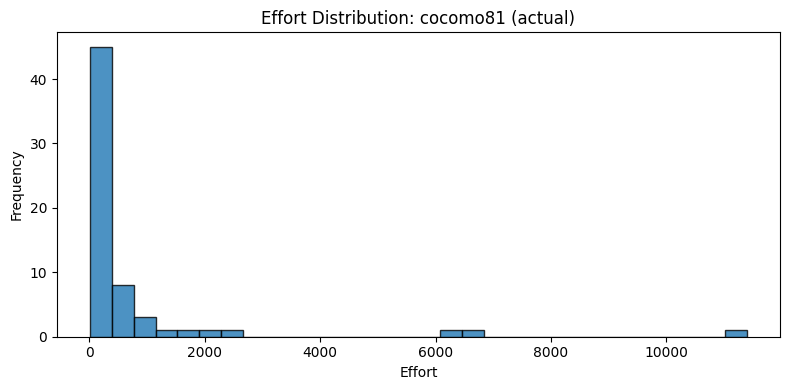

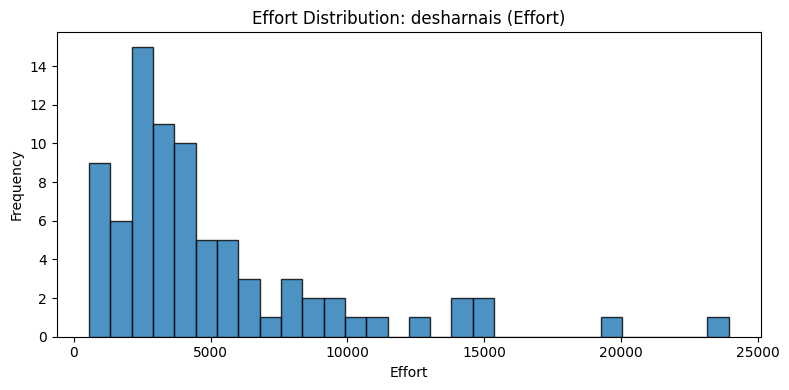

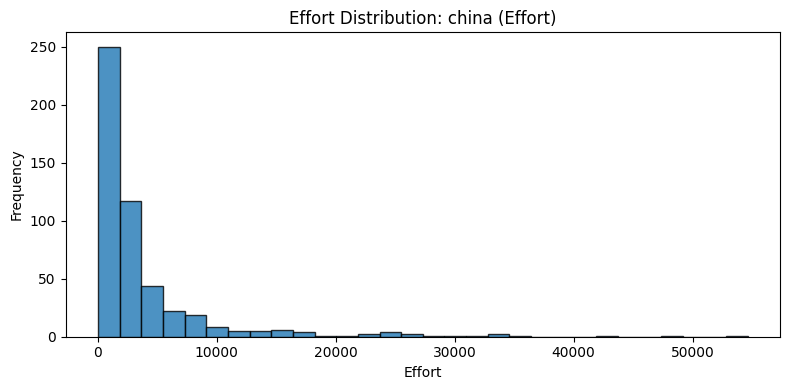

In [7]:
for name, df in datasets.items():
    effort_col = identify_effort_column(df)
    plt.figure(figsize=(8, 4))
    series = pd.to_numeric(df[effort_col], errors="coerce").dropna()
    plt.hist(series, bins=30, edgecolor="black", alpha=0.8)
    plt.title(f"Effort Distribution: {name} ({effort_col})")
    plt.xlabel("Effort")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()